# Airbnb Stock Price Prediction
- Data Cleaning
- EDA
- Ai Modelling

Hello guys ini adalah pelajaran pembuatan ai model machine learning pertamaku.  
Halo semuaaa hehe

``` print("Hello") ```

## 1. Data Loading And Data Pre-processing
Here i'm adding python libraries that is needed for making the Machine Learning Model  
I'm also adding the datasets that needed  
And then, i'm also doing some Data-preprocessing to get a cozy Dataframe

### Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math 

sns.set_theme(color_codes=True)

### Data loading

In [2]:
df = pd.read_csv('ABNB.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800
1,2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100
2,2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400
3,2020-12-16,125.830002,142.000000,124.910004,137.990005,137.990005,20409600
4,2020-12-17,143.000000,152.449997,142.669998,147.050003,147.050003,15054700


### Change 'Date' to Datetime64 and to an index
(Data Transformation)

In [3]:
# Cara ubah format kolom dan nama kolom:
# pilih kolom, df['Nama kolom'], lalu tulis = pd.to_apapun(df['Nama kolom baru'])
# Jika format tanggal di data lama itu unik, tambahkan (..., format='%Y-%m-%d')

df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

# Ubah data Date mu ke index untuk kemudahan coding dengan:
# df.set_index('Nama kolom', inplace=True)
# (Dataframe yang memakai 'Date' sebagai Index, berubah dari Tabel Biasa menjadi Time Series Object)

df.set_index('Date', inplace=True)

df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800
2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100
2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400
2020-12-16,125.830002,142.000000,124.910004,137.990005,137.990005,20409600
2020-12-17,143.000000,152.449997,142.669998,147.050003,147.050003,15054700


### Making sure all data filled

- Check Missing values/0
- Not check duplicates:  
because this data contect needs duplicate 


In [4]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,454.000000,454.000000,454.000000,454.000000,454.000000,4.540000e+02
mean,152.735925,156.465595,148.969855,152.729185,152.729185,6.690328e+06
std,28.340932,29.107813,27.490223,28.226659,28.226659,4.417387e+06
min,88.879997,91.459999,86.709999,89.080002,89.080002,1.995400e+06
25%,136.821507,139.842495,132.920002,135.955002,135.955002,4.114375e+06
50%,154.932495,159.099998,151.230004,155.654999,155.654999,5.450000e+06
75%,172.556507,175.974998,168.595005,171.744996,171.744996,7.631375e+06
max,216.240005,219.940002,209.089996,216.839996,216.839996,3.975500e+07


In [5]:
# Checking missing values
# True if there's missing values
print("True if theres missing values")
print(df.isnull().any(), '\n') 
# x > 0 if theres missing values
print("x > 0 if theres missing values")
print(df.isnull().sum(), '\n')
# x > 0 if theres 0 values
print("x > 0 if theres 0 values")
print((df == 0).any(), '\n')

True if theres missing values
Open         False
High         False
Low          False
Close        False
Adj Close    False
Volume       False
dtype: bool 

x > 0 if theres missing values
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64 

x > 0 if theres 0 values
Open         False
High         False
Low          False
Close        False
Adj Close    False
Volume       False
dtype: bool 



## 2. Exploratory Data Analysis

### Visualizing Stock Price Trends

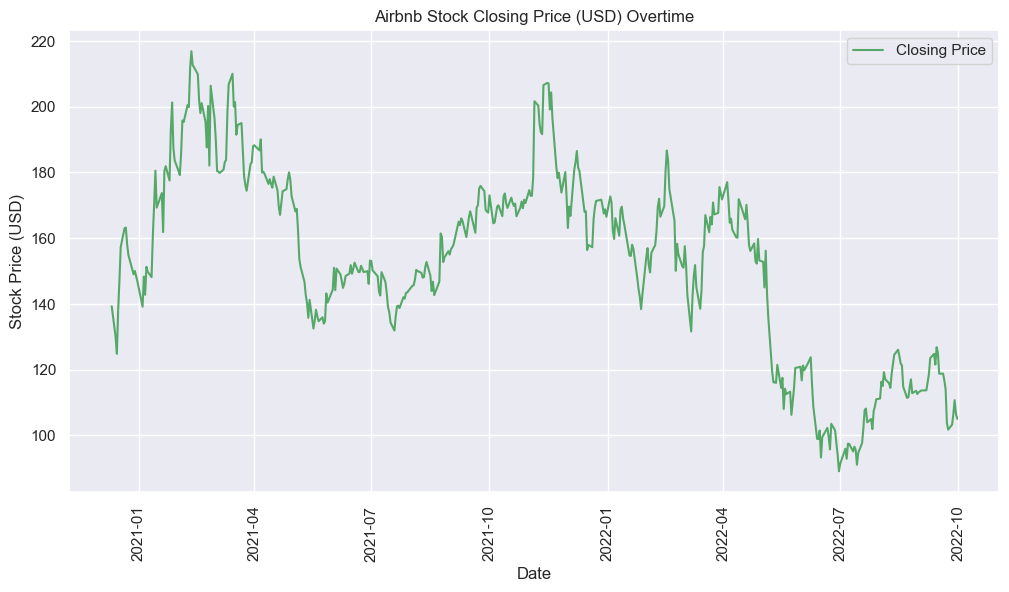

In [6]:
# Memvisualkan tren dari harga stock

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Closing Price', color='g')
plt.legend()
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.title("Airbnb Stock Closing Price (USD) Overtime")
plt.xticks(rotation=90)
plt.show()

In [7]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800
2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100
2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400
2020-12-16,125.830002,142.000000,124.910004,137.990005,137.990005,20409600
2020-12-17,143.000000,152.449997,142.669998,147.050003,147.050003,15054700


### Feature Engineering: Extracting Date Features

In [8]:
def create_datetime_feature(df):
  df['Year'] = df.index.year
  df['Month'] = df.index.month
  df['DayOfWeek'] = df.index.dayofweek
  return df

df = create_datetime_feature(df)

df.head(20)

,Open,High,Low,Close,Adj Close,Volume,Year,Month,DayOfWeek
Date,,,,,,,,,
2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800,2020,12,4
2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100,2020,12,0
2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400,2020,12,1
2020-12-16,125.830002,142.000000,124.910004,137.990005,137.990005,20409600,2020,12,2
2020-12-17,143.000000,152.449997,142.669998,147.050003,147.050003,15054700,2020,12,3
2020-12-18,150.449997,159.000000,150.300003,157.300003,157.300003,15954200,2020,12,4
2020-12-21,155.309998,172.000000,145.110001,163.020004,163.020004,17788100,2020,12,0
2020-12-22,170.000000,174.970001,161.050003,163.190002,163.190002,9872600,2020,12,1
2020-12-23,162.813995,168.250000,155.500000,158.009995,158.009995,5852500,2020,12,2


In [9]:
# # df['Close'].diff() akan mengurangi harga hari ini dengan harga kemarin.
# # Kalau hasilnya positif ( > 0 ) berarti Naik, negatif ( < 0 ) berarti Turun.

# # np.where itu ibarat IF-ELSE dalam satu baris.
# df['Status'] = np.where(df['Close'].diff() > 0, 'Naik', 
#                np.where(df['Close'].diff() < 0, 'Turun', 'Tetap/Awal'))

# # Karena baris pertama nggak punya hari kemarin, diff() nya bakal NaN.
# df['Status'].iloc[0] = 'Awal'

# # Liat hasilnya
# print(df[['Close', 'Status']].head(10))

#### Kesimpulan  sementara
Di awal minggu, orang orang kebanyakan membeli saham sehingga harganya menurun  
Akan tetapi, di akhir minggu, orang orang menjual saham sehingga harga naik  
Selain yang diatas, bisa jadi ada yang melakukan secara panik ntah karena berita atau hal lain

In [10]:
# Library untuk train dan test
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

## 3. Machine Learning Model for Stock Price Prediction

### Splitting Data into Train and Test Sets

In [11]:
X = df.drop(columns=['Close'])
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Model I: Decision Tree Regressor

In [12]:
# buat variabel model DTR
dtree = DecisionTreeRegressor(random_state=0)
# masukin data ke variabel DTR
dtree.fit(X_train, y_train)

# model predict
y_pred_dt = dtree.predict(X_test)

# alat ukur utk perbandingan model nanti
mae_dt = metrics.mean_absolute_error(y_test, y_pred_dt)
mse_dt = metrics.mean_squared_error(y_test, y_pred_dt)
r2_dt = metrics.r2_score(y_test, y_pred_dt)
rmse_dt = math.sqrt(mse_dt)

print(f"""
      Decision Tree Regressor
      MAE: {mae_dt}
      MSE: {mse_dt}
      R2: {r2_dt}
      RMSE: {rmse_dt}
      """)


      Decision Tree Regressor
      MAE: 0.3470327142857169
      MSE: 0.269499517831574
      R2: 0.9996783892298543
      RMSE: 0.5191334296995079
      


### Model II: Random Forest Regressor

In [13]:
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Alat ukur untuk perbandingan nanti
mae_rf = metrics.mean_absolute_error(y_test, y_pred_rf)
mse_rf = metrics.mean_squared_error(y_test, y_pred_rf)
r2_rf = metrics.r2_score(y_test, y_pred_rf)
rmse_rf = math.sqrt(mse_rf)

print(f"""
      Random Forest Regressor
      MAE: {mae_rf}
      MSE: {mse_rf}
      R2: {r2_rf}
      RMSE: {rmse_rf}
      """)


      Random Forest Regressor
      MAE: 0.29589454329670223
      MSE: 0.2637844988276057
      R2: 0.9996852093224394
      RMSE: 0.5135995510391396
      


### Conclusion  
Random Forest is more accurate based on:  
1. RF's MAE closer to zero than DT's MAE
2. RF's RMSE is closer to zero than DT's RMSE
3. RF's R^2 is closer to one than DT's R^2

Random Forest vs Decision Tree  
MAE: 0.29589454329670223 vs 0.3470327142857169 = RF closer to zero  
MSE: 0.2637844988276057 vs 0.269499517831574 = RF closer to zero(jarang dipakai)  
RMSE: 0.5135995510391396 vs 0.5191334296995079 = RF closer to zero  
R2: 0.9996852093224394 vs 0.9996783892298543 = RF closer to one  

## 4. Visualizing Predictions
### Adding Predictions to Dataset

In [14]:
df['Predicted_Close'] = rf.predict(X)

### Plot Actual vs Predicted Stock Prices

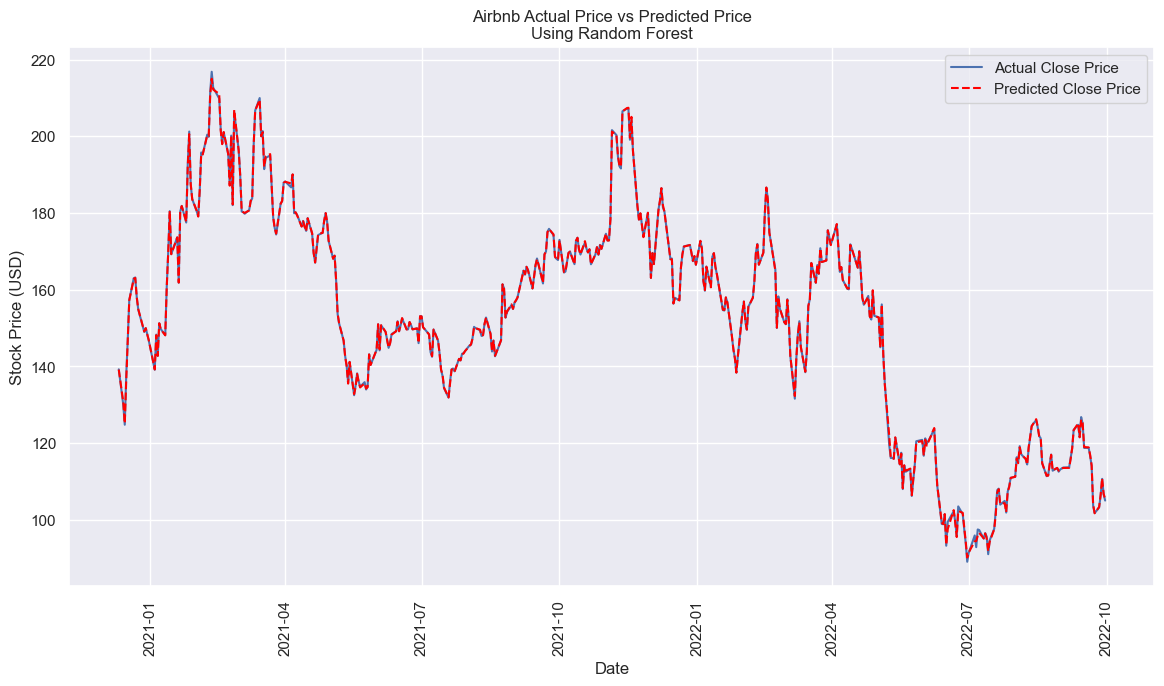

In [15]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Actual Close Price', color='b')
plt.plot(df.index, df['Predicted_Close'], label='Predicted Close Price', color='red', linestyle='dashed')
plt.legend()
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.title("Airbnb Actual Price vs Predicted Price\nUsing Random Forest")
plt.xticks(rotation=90)
plt.show()

## Final Conclusion
- We successfully built an Airbnb Stock Price Prediction model with Decision Tree and Random Forest  
- It's concluded that the Random Forest performed better than the Decision Tree, achieving a lower MAE and RMSE, indicating more accurate predictions  
- Visualization shows that the Random Forest model is highly accurate with the trends in the Airbnb Stock Price

## Inference
### Inputting to the prediction model


In [16]:
import yfinance as yf

airbnb = yf.Ticker("ABNB")

info = airbnb.info

rekomen = airbnb.recommendations

print(info, "\n")
print(rekomen)

{'address1': '888 Brannan Street', 'city': 'San Francisco', 'state': 'CA', 'zip': '94103', 'country': 'United States', 'phone': '(415) 728-0108', 'website': 'https://www.airbnb.com', 'industry': 'Travel Services', 'industryKey': 'travel-services', 'industryDisp': 'Travel Services', 'sector': 'Consumer Cyclical', 'sectorKey': 'consumer-cyclical', 'sectorDisp': 'Consumer Cyclical', 'longBusinessSummary': "Airbnb, Inc., together with its subsidiaries, operates a platform for stays, experiences, and services worldwide. The company's marketplace connects hosts and guests online or through mobile devices to book spaces, experiences, and services. It also offers gift cards. The company was formerly known as AirBed & Breakfast, Inc. and changed its name to Airbnb, Inc. in November 2010. Airbnb, Inc. was founded in 2007 and is headquartered in San Francisco, California.", 'fullTimeEmployees': 8200, 'companyOfficers': [{'maxAge': 1, 'name': 'Mr. Brian  Chesky', 'age': 43, 'title': 'Co-Founder, C

In [17]:
df_predik = yf.download("ABNB", period="1d", multi_level_index=False, auto_adjust=False)

df_predik.reset_index(inplace=True)
df_predik['Year'] = df_predik['Date'].dt.year
df_predik['Month'] = df_predik['Date'].dt.month
df_predik['DayOfWeek'] = df_predik['Date'].dt.dayofweek
df_predik

[*********************100%***********************]  1 of 1 completed


,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,DayOfWeek
0,2026-04-06,126.809998,126.809998,127.245003,124.279999,124.300003,2527600,2026,4,0


In [18]:
fitur_x = ['Open','High','Low', 'Adj Close', 'Volume','Year','Month','DayOfWeek']

X_input = df_predik[fitur_x]

hasil_prediksi = rf.predict(X_input)

print(f"Harga saham ABNB besok: {hasil_prediksi[0]}")

Harga saham ABNB besok: 127.01890162000005
